# DSC630-T302 Predictive Analytics
## 10.2 Assignment: Recommender System

**Student:** Adjovi Akpaki  
**Assignment:** 10.2 Recommender System  
**Dataset:** MovieLens Small Dataset  
**Method:** Item-based collaborative filtering with cosine similarity  

In this notebook, I build a working recommender system that allows a movie title from the MovieLens dataset to be entered and returns ten recommended movies. I document each code step carefully so the process, decisions, and analysis are clear.

## Assignment Goal

The goal of this assignment is to create a recommender system using the small MovieLens dataset. I use the rating history in the dataset to identify movies that are similar to a movie selected by the input title. I then return ten movies that may be good recommendations.

My approach is item-based collaborative filtering. In simple terms, I compare movies to other movies by looking at rating patterns. If the same users tend to rate two movies in similar ways, the movies are treated as similar. This makes sense for the assignment because I am recommending movies based on how movies relate to one another in the rating data.

In [1]:
# ============================================================
# Step 0: Import the libraries I need for this assignment
# ============================================================

# I import pandas because I need to load CSV files, inspect tables,
# merge datasets, reshape the ratings data, and display results.
import pandas as pd

# I import numpy because I need numerical operations for the recommender system.
# In this notebook, I use numpy to calculate cosine similarity manually.
import numpy as np

# I import matplotlib so I can create a simple chart that summarizes the rating data.
import matplotlib.pyplot as plt

# I import Path so I can safely work with file locations in Jupyter.
# This makes the notebook more reliable if the files are stored in the same folder
# or inside a common data folder.
from pathlib import Path

# I adjust pandas display settings so long movie titles do not get cut off in the output.
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 20)

# I print a short confirmation message so I know this setup cell ran successfully.
print("Libraries imported successfully. I am ready to load the MovieLens data.")

Libraries imported successfully. I am ready to load the MovieLens data.


## Step 1: Load the Data

The MovieLens small dataset normally includes several files. For this assignment, I only need two files:

- `movies.csv`, which contains the movie ID, title, and genre information.
- `ratings.csv`, which contains the user ratings for different movies.

I use a small helper function to find these files because students sometimes place the notebook and data inside different folders. This helps prevent a file-not-found error.

In [2]:
# ============================================================
# Step 1: Locate and load the MovieLens CSV files
# ============================================================

# I create a helper function so the notebook can search for a file in a few likely places.
# This is important because the assignment requires the data to be included with the submission,
# but the files may be stored directly beside the notebook or inside a folder.
def find_data_file(file_name):
    """
    I use this function to find a required data file.
    The function checks the current folder first, then common subfolders.
    If the file is not found, the function gives a clear error message.
    """

    # I list the most common places where the MovieLens files might be located.
    possible_locations = [
        Path(file_name),                         # same folder as the notebook
        Path("data") / file_name,               # data folder
        Path("ml-latest-small") / file_name,    # original MovieLens folder name
        Path("MovieLens") / file_name,          # another possible folder name
    ]

    # I loop through the possible locations and return the first one that exists.
    for location in possible_locations:
        if location.exists():
            return location

    # If none of the locations worked, I stop the notebook with a helpful message.
    raise FileNotFoundError(
        f"I could not find {file_name}. Please upload {file_name} in the same folder as this notebook."
    )

# I locate the movies file before reading it.
movies_path = find_data_file("movies.csv")

# I locate the ratings file before reading it.
ratings_path = find_data_file("ratings.csv")

# I read the movies file into a pandas DataFrame.
# This table gives me the movie title and genre for each movieId.
movies = pd.read_csv(movies_path)

# I read the ratings file into a pandas DataFrame.
# This table gives me the userId, movieId, rating, and timestamp values.
ratings = pd.read_csv(ratings_path)

# I print the exact file paths used so the loading step is transparent.
print(f"Movies file loaded from: {movies_path}")
print(f"Ratings file loaded from: {ratings_path}")

# I display the first few rows of each dataset so I can visually confirm the files loaded correctly.
print("\nFirst five rows of movies.csv:")
display(movies.head())

print("\nFirst five rows of ratings.csv:")
display(ratings.head())

Movies file loaded from: movies.csv
Ratings file loaded from: ratings.csv

First five rows of movies.csv:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



First five rows of ratings.csv:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Step 2: Verify the Data Structure

Before I create recommendations, I check whether the required columns are present. This step is important because the recommender system depends on `movieId`, `title`, `genres`, `userId`, and `rating`. If one of those columns is missing, the code should stop instead of producing unreliable results.

In [3]:
# ============================================================
# Step 2: Check that the required columns exist
# ============================================================

# I define the columns I expect to find in the movies file.
required_movie_columns = {"movieId", "title", "genres"}

# I define the columns I expect to find in the ratings file.
required_rating_columns = {"userId", "movieId", "rating"}

# I compare the required movie columns to the actual columns in the movies DataFrame.
missing_movie_columns = required_movie_columns - set(movies.columns)

# I compare the required rating columns to the actual columns in the ratings DataFrame.
missing_rating_columns = required_rating_columns - set(ratings.columns)

# I stop the notebook if required movie columns are missing.
if missing_movie_columns:
    raise ValueError(f"The movies file is missing these required columns: {missing_movie_columns}")

# I stop the notebook if required rating columns are missing.
if missing_rating_columns:
    raise ValueError(f"The ratings file is missing these required columns: {missing_rating_columns}")

# I print a confirmation when all required columns are present.
print("All required columns are present in the MovieLens files.")

# I show the columns so the reader can see exactly what is available.
print("\nMovies columns:", list(movies.columns))
print("Ratings columns:", list(ratings.columns))

All required columns are present in the MovieLens files.

Movies columns: ['movieId', 'title', 'genres']
Ratings columns: ['userId', 'movieId', 'rating', 'timestamp']


## Step 3: Explore the Dataset

I complete a basic review of the dataset before building the model. This helps me understand the size of the data, the number of users, the number of movies, the rating scale, missing values, and duplicates. This is part of documenting my process and making sure the model is based on usable data.

In [4]:
# ============================================================
# Step 3: Basic dataset review and quality checks
# ============================================================

# I calculate the number of rows and columns in the movies table.
movies_shape = movies.shape

# I calculate the number of rows and columns in the ratings table.
ratings_shape = ratings.shape

# I count how many unique users appear in the ratings data.
unique_users = ratings["userId"].nunique()

# I count how many unique movies appear in the movies table.
unique_movies_in_movies_file = movies["movieId"].nunique()

# I count how many unique movies actually received at least one rating.
unique_rated_movies = ratings["movieId"].nunique()

# I count missing values in each dataset to check for data quality issues.
movies_missing = movies.isna().sum()
ratings_missing = ratings.isna().sum()

# I count duplicate rows in each dataset.
movies_duplicates = movies.duplicated().sum()
ratings_duplicates = ratings.duplicated().sum()

# I organize the most important dataset facts into one summary table.
data_summary = pd.DataFrame({
    "Item": [
        "Movies table shape",
        "Ratings table shape",
        "Unique users",
        "Unique movies in movies file",
        "Unique movies with ratings",
        "Duplicate movie rows",
        "Duplicate rating rows"
    ],
    "Value": [
        str(movies_shape),
        str(ratings_shape),
        unique_users,
        unique_movies_in_movies_file,
        unique_rated_movies,
        movies_duplicates,
        ratings_duplicates
    ]
})

# I display the summary table so the dataset review is easy to read.
display(data_summary)

# I display missing values separately because it is important for data preparation.
print("Missing values in movies.csv:")
display(movies_missing)

print("Missing values in ratings.csv:")
display(ratings_missing)

,Item,Value
0,Movies table shape,"(9742, 3)"
1,Ratings table shape,"(100836, 4)"
2,Unique users,610
3,Unique movies in movies file,9742
4,Unique movies with ratings,9724
5,Duplicate movie rows,0
6,Duplicate rating rows,0


Missing values in movies.csv:


movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings.csv:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

## Step 4: Summarize Rating Behavior

The recommender system uses rating behavior to compare movies. I review the rating distribution because it shows how ratings are spread across the MovieLens scale. This also helps me explain the data before creating the recommendation model.

Rating summary:


count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Rating count by value:


,Number of Ratings
rating,
0.5,1370
1.0,2811
1.5,1791
2.0,7551
2.5,5550
3.0,20047
3.5,13136
4.0,26818
4.5,8551


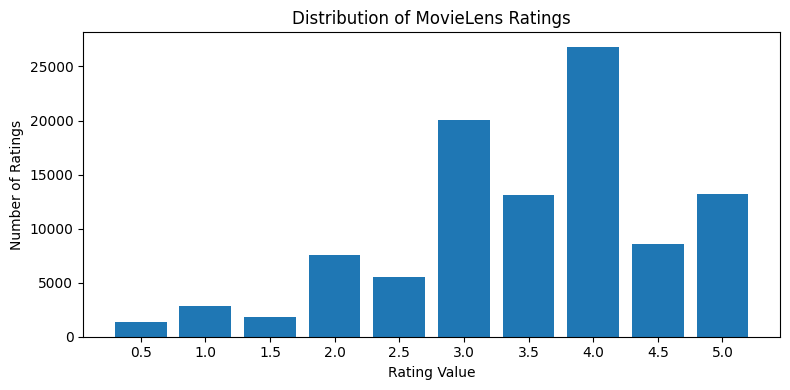

In [5]:
# ============================================================
# Step 4: Analyze the rating values
# ============================================================

# I summarize the rating column to see the count, average, minimum, maximum, and spread.
rating_summary = ratings["rating"].describe()

# I count how often each rating value appears.
rating_counts = ratings["rating"].value_counts().sort_index()

# I display the numeric summary of ratings.
print("Rating summary:")
display(rating_summary)

# I display the rating counts as a table.
print("Rating count by value:")
display(rating_counts.to_frame(name="Number of Ratings"))

# I create a bar chart to make the rating distribution easier to interpret.
plt.figure(figsize=(8, 4))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Distribution of MovieLens Ratings")
plt.xlabel("Rating Value")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

## Step 5: Merge Movies and Ratings

The ratings file contains `movieId`, but it does not contain the movie title. I merge the ratings table with the movies table so each rating record includes the movie title and genre. This makes the recommender system results easier to understand because the final recommendations can show movie names instead of only ID numbers.

In [6]:
# ============================================================
# Step 5: Merge the rating data with movie titles and genres
# ============================================================

# I merge ratings with movies using movieId because that is the shared key in both files.
ratings_with_movies = ratings.merge(movies, on="movieId", how="left")

# I check whether any ratings failed to match a movie title after the merge.
unmatched_titles = ratings_with_movies["title"].isna().sum()

# I print the result of the merge check.
print(f"Number of ratings without a matching movie title: {unmatched_titles}")

# I display the first rows of the merged dataset so the reader can see the combined fields.
display(ratings_with_movies.head())

Number of ratings without a matching movie title: 0


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


## Step 6: Create Movie-Level Statistics

Before recommending movies, I calculate the average rating and number of ratings for each movie. I use these values later to support the recommendation output. The average rating helps describe how viewers rated the movie, and the rating count helps identify whether a movie has enough rating support.

In [7]:
# ============================================================
# Step 6: Create movie-level rating statistics
# ============================================================

# I group by movieId and title so that each row represents one movie.
# I calculate the mean rating and the number of ratings for each movie.
movie_stats = (
    ratings_with_movies
    .groupby(["movieId", "title", "genres"], as_index=False)
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
)

# I round the average rating so the output table is cleaner.
movie_stats["average_rating"] = movie_stats["average_rating"].round(2)

# I sort the table by rating count to see the most commonly rated movies.
most_rated_movies = movie_stats.sort_values("rating_count", ascending=False).head(10)

# I display the most rated movies as a quick check of popularity in the data.
print("Top 10 movies by number of ratings:")
display(most_rated_movies[["title", "genres", "average_rating", "rating_count"]])

Top 10 movies by number of ratings:


,title,genres,average_rating,rating_count
314,Forrest Gump (1994),Comedy|Drama|Romance|War,4.16,329
277,"Shawshank Redemption, The (1994)",Crime|Drama,4.43,317
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.20,307
510,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.16,279
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.19,278
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,4.23,251
418,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,3.75,238
97,Braveheart (1995),Action|Drama|War,4.03,237
507,Terminator 2: Judgment Day (1991),Action|Sci-Fi,3.97,224
461,Schindler's List (1993),Drama|War,4.22,220


## Step 7: Create the Movie-User Matrix

To compare movies, I reshape the ratings data into a movie-user matrix. Each row is a movie and each column is a user. The values are the ratings. If a user did not rate a movie, the value is missing. For cosine similarity, I fill missing ratings with 0. This does not mean the user rated the movie as zero; it only creates a numeric matrix so similarity can be calculated.

In [8]:
# ============================================================
# Step 7: Build the movie-user rating matrix
# ============================================================

# I create a pivot table where each row is a movie and each column is a user.
# The cells contain the rating that a user gave to a movie.
movie_user_matrix = ratings.pivot_table(
    index="movieId",
    columns="userId",
    values="rating"
)

# I fill missing ratings with 0 because cosine similarity needs numeric values.
# In this context, 0 means "no rating available," not a real rating of zero.
movie_user_matrix_filled = movie_user_matrix.fillna(0)

# I print the size of the matrix so the reader can see how many movies and users are compared.
print("Movie-user matrix shape:", movie_user_matrix_filled.shape)

# I display a small sample of the matrix to show what the model input looks like.
display(movie_user_matrix_filled.head())

Movie-user matrix shape: (9724, 610)


userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 8: Calculate Cosine Similarity

I use cosine similarity to compare movies. Cosine similarity measures whether two movies have similar rating patterns across users. A value closer to 1 means the two movies are more similar based on the ratings in the dataset. I calculate cosine similarity manually with NumPy so the notebook does not depend on extra packages beyond pandas, NumPy, and matplotlib.

In [9]:
# ============================================================
# Step 8: Calculate item-based cosine similarity manually
# ============================================================

# I convert the movie-user matrix into a NumPy array so I can use matrix calculations.
ratings_matrix = movie_user_matrix_filled.to_numpy()

# I calculate the length, or norm, of each movie vector.
# This is needed for the cosine similarity formula.
movie_norms = np.linalg.norm(ratings_matrix, axis=1)

# I replace any zero norms with a very small number to avoid division by zero.
# This is a safety step in case a movie has no rating vector after processing.
movie_norms[movie_norms == 0] = 1e-12

# I divide each movie vector by its norm to create normalized movie vectors.
normalized_movie_vectors = ratings_matrix / movie_norms[:, np.newaxis]

# I calculate cosine similarity by multiplying the normalized matrix by its transpose.
# The result is a square matrix where each cell represents similarity between two movies.
cosine_similarity_matrix = np.dot(normalized_movie_vectors, normalized_movie_vectors.T)

# I convert the similarity matrix into a DataFrame so I can label rows and columns by movieId.
movie_similarity = pd.DataFrame(
    cosine_similarity_matrix,
    index=movie_user_matrix_filled.index,
    columns=movie_user_matrix_filled.index
)

# I print the shape of the similarity matrix to confirm the calculation worked.
print("Movie similarity matrix shape:", movie_similarity.shape)

# I display a small portion of the similarity matrix.
display(movie_similarity.iloc[:5, :5])

Movie similarity matrix shape: (9724, 9724)


movieId,1,2,3,4,5
movieId,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762
2,0.410562,1.000000,0.282438,0.106415,0.287795
3,0.296917,0.282438,1.000000,0.092406,0.417802
4,0.035573,0.106415,0.092406,1.000000,0.188376
5,0.308762,0.287795,0.417802,0.188376,1.000000


## Step 9: Create a Title Search Helper

The assignment requires the recommender system to allow a movie title from the dataset to be entered. Exact titles can be difficult because the MovieLens title includes the year. I create a title search function so I can find valid movie titles before using the recommender function.

In [10]:
# ============================================================
# Step 9: Create a title search helper function
# ============================================================

# I create this function to search the MovieLens title list.
# It helps me find exact movie titles that can be used as input.
def search_movie_titles(search_text, max_results=15):
    """
    I use this function to search for movies by title.
    The function is not the recommender itself; it helps identify valid titles in the dataset.
    """

    # I convert the search text to lowercase to make the search case-insensitive.
    search_text = str(search_text).lower().strip()

    # I find all movie rows where the lowercase title contains the search text.
    matches = movies[movies["title"].str.lower().str.contains(search_text, na=False)]

    # I return a small table of matching titles so the output is easy to read.
    return matches[["movieId", "title", "genres"]].head(max_results)

# I test the search helper with the word "Toy" because Toy Story is a common example in MovieLens.
search_movie_titles("Toy")

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1492,2017,Babes in Toyland (1961),Children|Fantasy|Musical
1674,2253,Toys (1992),Comedy|Fantasy
2329,3086,Babes in Toyland (1934),Children|Comedy|Fantasy|Musical
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
3595,4929,"Toy, The (1982)",Comedy
4089,5843,Toy Soldiers (1991),Action|Drama
7355,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX


## Step 10: Build the Recommendation Function

This is the main function for the assignment. The function takes a movie title as input and returns ten other recommended movies. I also include a few practical rules:

1. I remove the selected movie from its own recommendation list.
2. I merge similarity results with movie titles, genres, average rating, and rating count.
3. I include a weighted rating score so movies with very few ratings are not treated the same as movies with stronger rating support.
4. I sort the results using similarity first and rating support second.

In [11]:
# ============================================================
# Step 10: Define the recommender function
# ============================================================

# I create a recommender function that accepts a movie title and returns ten recommended movies.
def recommend_movies(movie_title, number_of_recommendations=10):
    """
    I use this function to recommend movies based on a movie title.

    Inputs:
    - movie_title: the movie title typed by the person using the notebook.
    - number_of_recommendations: how many movie recommendations I want to return.

    Output:
    - a table of recommended movies with similarity, genre, average rating, and rating count.
    """

    # I clean the input title by removing extra spaces.
    movie_title = str(movie_title).strip()

    # I look for an exact title match in the movies table.
    title_matches = movies[movies["title"].str.lower() == movie_title.lower()]

    # If I do not find an exact match, I provide helpful guidance instead of letting the code fail.
    if title_matches.empty:
        possible_matches = search_movie_titles(movie_title, max_results=10)
        raise ValueError(
            "I could not find an exact movie title match. "
            "Please use one of the exact titles from the dataset. "
            "Run search_movie_titles('your movie') to find valid titles. "
            f"Possible matches found:\n{possible_matches.to_string(index=False)}"
        )

    # I select the first matching movieId.
    # In MovieLens, titles are generally unique with the year included.
    selected_movie_id = title_matches.iloc[0]["movieId"]

    # I make sure the selected movie has ratings in the movie-user matrix.
    # A movie without ratings cannot be compared using collaborative filtering.
    if selected_movie_id not in movie_similarity.index:
        raise ValueError("This movie exists in movies.csv, but it does not have ratings available for comparison.")

    # I retrieve similarity scores between the selected movie and all other movies.
    similarity_scores = movie_similarity[selected_movie_id].sort_values(ascending=False)

    # I remove the selected movie itself because the assignment asks for other movies to watch.
    similarity_scores = similarity_scores.drop(index=selected_movie_id)

    # I convert the similarity scores to a DataFrame so I can merge them with movie information.
    recommendation_table = similarity_scores.reset_index()
    recommendation_table.columns = ["movieId", "similarity_score"]

    # I merge similarity results with movie title, genre, average rating, and rating count.
    recommendation_table = recommendation_table.merge(movie_stats, on="movieId", how="left")

    # I create a weighted rating to reduce the impact of movies with very few ratings.
    # This is not the main recommender score; it is supporting information for ranking and interpretation.
    overall_average_rating = movie_stats["average_rating"].mean()
    minimum_rating_support = movie_stats["rating_count"].quantile(0.60)

    recommendation_table["weighted_rating"] = (
        (recommendation_table["rating_count"] / (recommendation_table["rating_count"] + minimum_rating_support))
        * recommendation_table["average_rating"]
        + (minimum_rating_support / (recommendation_table["rating_count"] + minimum_rating_support))
        * overall_average_rating
    )

    # I round the numeric columns to make the final output easier to read.
    recommendation_table["similarity_score"] = recommendation_table["similarity_score"].round(4)
    recommendation_table["weighted_rating"] = recommendation_table["weighted_rating"].round(2)

    # I sort primarily by similarity because this is an item-based recommender.
    # I use weighted rating and rating count as secondary support measures.
    recommendation_table = recommendation_table.sort_values(
        by=["similarity_score", "weighted_rating", "rating_count"],
        ascending=[False, False, False]
    )

    # I return the number of recommendations requested.
    return recommendation_table[[
        "title",
        "genres",
        "similarity_score",
        "average_rating",
        "rating_count",
        "weighted_rating"
    ]].head(number_of_recommendations)

In [12]:
from IPython.display import display

# I test the recommender system using an exact movie title from the dataset.
recommendations = recommend_movies("Toy Story (1995)")

# I display the recommendation table.
display(recommendations)

,title,genres,similarity_score,average_rating,rating_count,weighted_rating
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.5726,3.86,97,3.84
1,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.5656,3.75,238,3.74
2,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,0.5643,3.45,202,3.45
3,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.5574,4.23,251,4.21
4,Forrest Gump (1994),Comedy|Drama|Romance|War,0.5471,4.16,329,4.15
6,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.5411,4.14,196,4.12
5,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.5411,3.94,172,3.92
7,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller,0.5389,3.54,162,3.53
8,Groundhog Day (1993),Comedy|Fantasy|Romance,0.5342,3.94,143,3.92
9,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.5304,4.04,171,4.02


## Step 11: Test the Recommender System

I test the recommender system using an exact movie title from the dataset. I choose **Toy Story (1995)** because it is a well-known movie and is included in the MovieLens dataset. The table below shows the ten movies recommended by the system.

In [13]:
# ============================================================
# Step 11: Run the recommender using an example movie
# ============================================================

# I choose an exact title from the MovieLens dataset.
example_movie = "Toy Story (1995)"

# I run my recommender function and ask for ten recommendations.
toy_story_recommendations = recommend_movies(example_movie, number_of_recommendations=10)

# I print the input movie so the recommendation output has context.
print(f"Input movie: {example_movie}")
print("Ten recommended movies:")

# I display the recommendation table.
display(toy_story_recommendations)

Input movie: Toy Story (1995)
Ten recommended movies:


,title,genres,similarity_score,average_rating,rating_count,weighted_rating
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.5726,3.86,97,3.84
1,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.5656,3.75,238,3.74
2,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,0.5643,3.45,202,3.45
3,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.5574,4.23,251,4.21
4,Forrest Gump (1994),Comedy|Drama|Romance|War,0.5471,4.16,329,4.15
6,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.5411,4.14,196,4.12
5,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.5411,3.94,172,3.92
7,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller,0.5389,3.54,162,3.53
8,Groundhog Day (1993),Comedy|Fantasy|Romance,0.5342,3.94,143,3.92
9,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.5304,4.04,171,4.02


## Step 12: Test a Second Movie

I also test the system with another movie title to show that the recommender function is reusable. This step helps demonstrate that the system is not hard-coded only for one movie.

In [14]:
# ============================================================
# Step 12: Run the recommender using a second example movie
# ============================================================

# I choose a second exact title from the dataset.
second_example_movie = "Jumanji (1995)"

# I generate ten recommendations for the second movie.
second_recommendations = recommend_movies(second_example_movie, number_of_recommendations=10)

# I display the second input and the related recommendations.
print(f"Input movie: {second_example_movie}")
print("Ten recommended movies:")
display(second_recommendations)

Input movie: Jumanji (1995)
Ten recommended movies:


,title,genres,similarity_score,average_rating,rating_count,weighted_rating
0,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.5884,3.94,172,3.92
1,Mrs. Doubtfire (1993),Comedy|Drama,0.5498,3.39,144,3.39
2,"Mask, The (1994)",Action|Comedy|Crime|Fantasy,0.5450,3.18,157,3.18
3,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.5380,3.75,238,3.74
4,Home Alone (1990),Children|Comedy,0.5249,3.00,116,3.01
5,"Nightmare Before Christmas, The (1993)",Animation|Children|Fantasy|Musical,0.5182,3.55,93,3.54
6,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,0.5156,3.79,183,3.78
7,Beauty and the Beast (1991),Animation|Children|Fantasy|Musical|Romance|IMAX,0.5075,3.77,146,3.76
8,Ace Ventura: When Nature Calls (1995),Comedy,0.4976,2.73,88,2.75
9,"Santa Clause, The (1994)",Comedy|Drama|Fantasy,0.4974,3.20,81,3.20


## Step 13: Explain How the Recommendation Process Works

The recommender system follows these steps:

1. I load the MovieLens `movies.csv` and `ratings.csv` files.
2. I check that the required columns are present.
3. I review the dataset structure, missing values, duplicates, and rating distribution.
4. I merge movie titles and genres with the rating records.
5. I create a movie-user matrix where rows are movies and columns are users.
6. I fill missing values with 0 so cosine similarity can be calculated.
7. I calculate cosine similarity between movies using user rating patterns.
8. I create a function that accepts a movie title and returns the ten most similar movies.
9. I include rating count and weighted rating information to make the output easier to evaluate.

This process meets the assignment requirement because a person can input a movie title from the dataset and receive ten recommended movies.

In [15]:
# ============================================================
# Step 13: Create a final process summary table
# ============================================================

# I create a simple table that documents the major steps I performed.
process_summary = pd.DataFrame({
    "Step": [
        "Load data",
        "Check structure",
        "Explore ratings",
        "Merge data",
        "Build matrix",
        "Calculate similarity",
        "Recommend movies",
        "Interpret output"
    ],
    "What I Did": [
        "I loaded movies.csv and ratings.csv.",
        "I confirmed that the required columns were available.",
        "I reviewed the rating scale, counts, missing values, and duplicates.",
        "I joined movie titles and genres to the rating records.",
        "I created a movie-user matrix with movies as rows and users as columns.",
        "I calculated cosine similarity between movie rating vectors.",
        "I built a function that returns ten recommended movies for an input title.",
        "I reviewed similarity score, genre, average rating, rating count, and weighted rating."
    ],
    "Why It Matters": [
        "The recommender needs both movie names and rating behavior.",
        "The model should only be built if the required data fields exist.",
        "Exploration helps me understand whether the dataset is usable.",
        "The final recommendations need readable movie titles, not only IDs.",
        "The matrix is the main input for item-based collaborative filtering.",
        "Similarity scores identify movies with similar rating patterns.",
        "This directly answers the assignment requirement.",
        "These fields make the recommendations easier to explain."
    ]
})

# I display the process summary so the notebook clearly documents my workflow.
display(process_summary)

,Step,What I Did,Why It Matters
0,Load data,I loaded movies.csv and ratings.csv.,The recommender needs both movie names and rating behavior.
1,Check structure,I confirmed that the required columns were available.,The model should only be built if the required data fields exist.
2,Explore ratings,"I reviewed the rating scale, counts, missing values, and duplicates.",Exploration helps me understand whether the dataset is usable.
3,Merge data,I joined movie titles and genres to the rating records.,"The final recommendations need readable movie titles, not only IDs."
4,Build matrix,I created a movie-user matrix with movies as rows and users as columns.,The matrix is the main input for item-based collaborative filtering.
5,Calculate similarity,I calculated cosine similarity between movie rating vectors.,Similarity scores identify movies with similar rating patterns.
6,Recommend movies,I built a function that returns ten recommended movies for an input title.,This directly answers the assignment requirement.
7,Interpret output,"I reviewed similarity score, genre, average rating, rating count, and weighted rating.",These fields make the recommendations easier to explain.


## Limitations

This recommender system is useful for the assignment, but it has limitations. First, it uses historical ratings from the small MovieLens dataset, so it can only recommend movies that are already included in the data. Second, collaborative filtering depends on rating patterns, so movies with very few ratings may have weaker similarity results. Third, the system does not know a person’s personal preferences unless those preferences are reflected in the rating data.

Even with those limitations, the system gives a working and explainable recommendation process. It uses the available rating behavior to identify similar movies and returns ten recommendations for a selected title.

## Conclusion

In this assignment, I created a working recommender system using the small MovieLens dataset. I designed the system so that a movie title from the dataset can be entered and the system returns ten recommended movies. I used item-based collaborative filtering because it compares movies to other movies based on rating patterns, which is appropriate for this type of assignment.

This process helped me better understand how recommender systems use past rating behavior to identify similarities between items. I also included average rating, rating count, weighted rating, and genre information so the recommendation output would be easier to interpret. Overall, the notebook meets the assignment requirements because it creates a recommender system, produces ten recommendations, documents each step, and explains the process in clear language.

## References

GroupLens. (n.d.). *MovieLens datasets*. University of Minnesota. https://grouplens.org/datasets/movielens/

Harper, F. M., & Konstan, J. A. (2015). The MovieLens datasets: History and context. *ACM Transactions on Interactive Intelligent Systems, 5*(4), 1-19. https://doi.org/10.1145/2827872